## Análise de Presença e Evoluação de Pesquisa do Público Científico da SBC

#### Bibliotecas e Funções Gerais

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import re
import seaborn as sns
from langdetect import detect
from collections import Counter

In [ ]:
def normalizar_texto_maiusculo_sem_acento(texto):
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    return texto.upper()

def remover_afiliacao(texto):
    """
    Remove qualquer conteúdo entre parênteses, ex: (UFF)
    """
    return re.sub(r"\s*\(.*?\)", "", texto).strip()

def normalizar_autores(campo):
    if pd.isna(campo):
        return campo

    autores = campo.split(";")
    autores_formatados = []

    for autor in autores:
        autor = autor.strip()

        # Remove afiliação institucional (ex: (UFF))
        autor = remover_afiliacao(autor)

        # Inversão SOMENTE se houver vírgula
        if "," in autor:
            sobrenome, restante = autor.split(",", 1)
            nome_completo = f"{restante.strip()} {sobrenome.strip()}"
        else:
            nome_completo = autor

        # Normalização final
        nome_completo = normalizar_texto_maiusculo_sem_acento(nome_completo)

        autores_formatados.append(nome_completo)

    return "; ".join(autores_formatados)

In [ ]:
def analisar_genero_autores(campo):
    # Caso NaN
    if pd.isna(campo):
        return pd.Series([None, 0, 0, 0, 0])

    autores = [a.strip() for a in campo.split(";") if a.strip()]

    # Caso string vazia ou sem autores válidos
    if not autores:
        return pd.Series([None, 0, 0, 0, 0])

    # Número total de autores
    qtd_autores = len(autores)

    primeiros_nomes = [autor.split()[0] for autor in autores]

    # Classificação usando o df_censo
    generos = [mapa_sexo.get(nome, "unknown") for nome in primeiros_nomes]

    # 1. Sexo do primeiro autor
    sexo_primeiro_autor = generos[0]

    # 2. Quantidade de autoras
    qtd_feminino = generos.count("F")

    # 3. Quantidade de autores masculinos
    qtd_masculino = generos.count("M")

    # 4. Quantidade de unknown
    qtd_unknown = generos.count("unknown")

    return pd.Series([
        sexo_primeiro_autor,
        qtd_feminino,
        qtd_masculino,
        qtd_unknown,
        qtd_autores
    ])

### Aplicação de Detecção de Gênero

* Número de Autoras Principais (Considera-se aqui o primeiro nome como o Autor Principal)
* Quantidade de Autores do Gênero Feminino
* Quantidade de Autores do Gênero Masculino
* Quantidade Total de Autores
* Quantidade de nomes por artigos categorizados como Desconhecidos

Usou-se, inicialmente, A relação dos 10 mil nomes mais frequentes por gênero do IBGE e dado o elevado número de participantes classificados como desconhecidos, utilizou-se o gende_guesser_br para classificação dos gêneros de cada um dos nomes desconhecidos.

Os nomes que ganharam uma categoria enriqueceram a antiga base do IBGE, diminuindo assim o número de autores e autorras com o gênero desconhecido

#### Abordagem Censo IBGE de Nomes

In [ ]:
# Inicialmente usou-se o dataset abaixo

df_censo = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\1_censo_nomes_IBGE.csv')
df_censo.info()

In [ ]:
df_censo = (
    df_censo
    .sort_values("freq", ascending=False)
    .drop_duplicates(subset="nome", keep="first")
    [["nome", "sexo"]]
    .reset_index(drop=True)
)

In [ ]:
df_censo.info()

In [ ]:
df_censo.head()

In [ ]:
df_artigos = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\2_metadados_completos_sol_sbc.csv')

In [ ]:
df_artigos["autores_tratados"] = df_artigos["Authors"].apply(normalizar_autores)

In [ ]:
df_artigos.head()

In [ ]:
mapa_sexo = dict(zip(df_censo["nome"], df_censo["sexo"]))

In [ ]:
df_artigos[
    [
        "Sexo Primeiro Autor",
        "Qtd Autores Feminino",
        "Qtd Autores Masculino",
        "Qtd Autores Unknown",
        "Qtd Autores Total"
    ]
] = df_artigos["autores_tratados"].apply(analisar_genero_autores)

In [ ]:
df_artigos['Ano'] = df_artigos['Date'].str.extract(r'(\d{4})')

In [ ]:
colunas = [
    "Qtd Autores Feminino",
    "Qtd Autores Masculino",
    "Qtd Autores Unknown",
    "Qtd Autores Total",
    "Ano"
]

df_artigos[colunas] = df_artigos[colunas].astype("Int64")

In [ ]:
df_artigos.head()

In [ ]:
df_artigos.to_csv('3_metadados_completos_sol_sbc_com_genero.csv', index=False)

In [ ]:
# Trecho de Código que da origem ao 4_metadados_completos_sol_sbc_com_genero_desconhecido.csv

#### Relação de Nomes Desconhecidos (Usar Apenas para Descobrir o Gênero dos Nomes Desconhecidos)

In [ ]:
# O Dataset abaixo contempla todos os registros com ao menos 1 autor previamente classificado como Desconhecido

df_desconhecidos = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\4_metadados_completos_sol_sbc_com_genero_desconhecido.csv')   
df_desconhecidos.info()

In [ ]:
import pandas as pd

def extrair_primeiros_nomes(campo):
    if pd.isna(campo):
        return []

    autores = [a.strip() for a in campo.split(";") if a.strip()]
    primeiros_nomes = [
        autor.split()[0].strip()
        for autor in autores
        if autor.split()
    ]
    return primeiros_nomes

In [ ]:
df_nomes_desconhecidos = (
    df_desconhecidos
    .assign(primeiro_nome=df_desconhecidos["autores_tratados"].apply(extrair_primeiros_nomes))
    .explode("primeiro_nome")
    .dropna(subset=["primeiro_nome"])
)

In [ ]:
df_nomes_desconhecidos.info()

In [ ]:
df_nomes_desconhecidos = df_nomes_desconhecidos[["primeiro_nome"]]

In [ ]:
df_nomes_desconhecidos.head()

In [ ]:
df_nomes_desconhecidos = (
    df_nomes_desconhecidos
    .drop_duplicates()
    .sort_values("primeiro_nome")
    .reset_index(drop=True)
)

In [ ]:
df_nomes_desconhecidos.info()

In [ ]:
df_nomes_desconhecidos["genero"] = df_nomes_desconhecidos.apply(lambda row: Genero(row["primeiro_nome"])(), axis=1)

In [ ]:
df_nomes_desconhecidos.head()

In [ ]:
df_nomes_desconhecidos.to_csv('5_classificacao_nomes_desconhecidos_gender_guesser.csv', index=False)

In [ ]:
# Trecho de código que incorpora dá origem ao dataset_final_censo

#### Construção do Dataset Final

In [ ]:
# Os nomes que obtiveram classificação via Gender Guesser foram incorporados manualmente ao dataset do censo, 
# resultando no dataset abaixo 

df_censo = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\6_dataset_final_censo.csv')

In [ ]:
# Usa-se novamente a base de metadados_completos_sol_sbc.csv e a classificação é feita mais uma vez

df_artigos = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\2_metadados_completos_sol_sbc.csv')
df_artigos["autores_tratados"] = df_artigos["Authors"].apply(normalizar_autores)

In [ ]:
mapa_sexo = dict(zip(df_censo["nome"], df_censo["sexo"]))

In [ ]:
df_artigos[
    [
        "Sexo Primeiro Autor",
        "Qtd Autores Feminino",
        "Qtd Autores Masculino",
        "Qtd Autores Unknown",
        "Qtd Autores Total"
    ]
] = df_artigos["autores_tratados"].apply(analisar_genero_autores)

In [ ]:
# Extrair o ano de publicação
df_artigos['Ano'] = df_artigos['Date'].str.extract(r'(\d{4})')

In [ ]:
colunas = [
    "Qtd Autores Feminino",
    "Qtd Autores Masculino",
    "Qtd Autores Unknown",
    "Qtd Autores Total",
    "Ano"
]

df_artigos[colunas] = df_artigos[colunas].astype("Int64")

In [ ]:
df_artigos.head()

In [ ]:
df_artigos.to_csv('3_metadados_completos_sol_sbc_com_genero.csv', index=False)

### Pré-Processamento Textual

In [30]:
!pip install spacy
!python -m spacy download pt_core_news_sm
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.8.0/pt_core_news_sm-3.8.0-py3-none-any.whl (13.0 MB)
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 2.9 MB/s eta 0:00:05
     ----- ---------------------------------- 1.8/12.8 MB 5.2 MB/s eta 0:00:03
     --------- ------------------------------ 2.9/12.8 MB 5.3 MB/s eta 0:00:02
     ------------- -------------------------- 4.5/12.8 MB 5.7 MB/s eta 0:00:02
     ------------------ --------------------- 5.8/12.8 MB 5.8 MB/s eta 0:00:02
     ---------------------- ----------------- 7.1/12.8 MB 6.0 MB/s eta 0:00:01
     --------------------------- ------------ 8.7/12.8 MB 6.1 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 6.2 MB/s eta 0:00:01
     ---------------------------------- ----- 11.0/12.8 MB 5.9 MB/s eta 0:00:01
     -------------------------------------- - 12.3/12.8 MB 6.1 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 6.1 M


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
#Importando bibliotecas básicas para pré-processamento
import re
import time
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from unicodedata import normalize
import spacy

In [ ]:
df_artigos = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\3_metadados_completos_sol_sbc_com_genero.csv')
df_artigos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30095 entries, 0 to 30094
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Title                  29781 non-null  object 
 1   Category               29781 non-null  object 
 2   URL_Title              29781 non-null  object 
 3   Authors                29781 non-null  object 
 4   Event                  29781 non-null  object 
 5   Date                   29781 non-null  object 
 6   Abstract               29780 non-null  object 
 7   autores_tratados       29781 non-null  object 
 8   Sexo Primeiro Autor    29772 non-null  object 
 9   Qtd Autores Feminino   30095 non-null  int64  
 10  Qtd Autores Masculino  30095 non-null  int64  
 11  Qtd Autores Unknown    30095 non-null  int64  
 12  Qtd Autores Total      30095 non-null  int64  
 13  Ano                    29781 non-null  float64
dtypes: float64(1), int64(4), object(9)
memory usage: 3.2+ 

In [40]:
#Adicionando coluna ID_ARTIGO
df_artigos["id_artigo"] = range(1, len(df_artigos) + 1)

In [ ]:
def detectar_idioma(texto):
    try:
        return detect(texto)
    except:
        return "unknown"

df_artigos["Idioma_Abstract"] = df_artigos["Abstract"].fillna("").apply(detectar_idioma)

In [42]:
# Garantir nomes padronizados
df_artigos.columns = df_artigos.columns.str.strip().str.replace(' ', '_')

# Converter colunas para tipos adequados (segurança)
df_artigos['Ano'] = pd.to_numeric(df_artigos['Ano'], errors='coerce')
df_artigos['Qtd_Autores_Feminino'] = pd.to_numeric(df_artigos['Qtd_Autores_Feminino'], errors='coerce')
df_artigos['Qtd_Autores_Masculino'] = pd.to_numeric(df_artigos['Qtd_Autores_Masculino'], errors='coerce')

df_artigos["Ano"] = df_artigos["Ano"].astype("Int64")

In [ ]:
nlp_pt = spacy.load('pt_core_news_sm')
nlp_en = spacy.load("en_core_web_sm")
nltk.download('punkt_tab')

# Pré-processamento - ABSTRACT

#Contabilizando o tempo de execução - Início
start_time = time.time()

#Pré-Processamento do Abstract
map_abstract = {}

for line, column in df_artigos.iterrows():
    
    id_artigo = column['id_artigo']
    abstract = column['Abstract']
    idioma = column['Idioma_Abstract']
    
    if pd.notna(abstract):

        text = abstract

        #Remoção simples de quebras de linha
        text = re.sub(r'\n', ' ', text)

        #Remoção de caracteres de pontuação
        text = re.sub(r'[^\w\s]', ' ', text)

        #Removendo espaços extras
        text = ' '.join(text.split())

        #Descapitalização
        text = text.lower()

        #Escolha do modelo de idioma
        if idioma == 'pt':
            doc = nlp_pt(text)
        else:
            doc = nlp_en(text)

        #Tokenização + Lematização
        tokens = [
            token.lemma_
            for token in doc
            if token.is_alpha
            and len(token) > 1
        ]

    else:
        tokens = []

    map_abstract[id_artigo] = tokens


df_artigos['abstract_pre_processado'] = df_artigos['id_artigo'].map(map_abstract)

df_artigos.to_csv('7_metadados_completos_sol_sbc_com_genero_pre_processamento_abstract.csv')

#Contabilizando o tempo de execução da célula - Fim
end_time = time.time()

elapsed_time = end_time - start_time

hours, remainder = divmod(elapsed_time, 3600)
minutes, seconds = divmod(remainder, 60)

#Imprime o tempo de execução da célula
print(f'Tempo de execução: {int(hours)} horas, {int(minutes)} minutos e {int(seconds)} segundos.')

[nltk_data] Downloading package punkt_tab to C:\Users\Thiago
[nltk_data]     Lobo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Tempo de execução: 0 horas, 11 minutos e 8 segundos.


In [ ]:
# Análise de Frequência de Palavras nos Abstracts pós Lematização

todas_palavras = []

for tokens in df_artigos["abstract_pre_processado"].dropna():
    todas_palavras.extend(tokens)

frequencia = Counter(todas_palavras)

# converter para dataframe
df_frequencia = (
    pd.DataFrame(frequencia.items(), columns=["Palavra", "Frequencia"])
    .sort_values(by="Frequencia", ascending=False)
)

print(df_frequencia.head(50))

#df_frequencia.to_csv('8_frequencia_palavras_abstracts.csv', index=False)

         Palavra  Frequencia
2013          de      157558
14           the      112663
4260        de o       73961
19            of       68745
16           and       60795
70            to       52707
4127          um       47870
71            be       46758
6             in       44220
4306        para       36500
4292        em o       35408
4272          em       32256
4307           o       31769
4336         que       27910
4331         ser       25494
43           for       22052
39          this       21906
1498         com       21104
46          that       18614
49          with       15813
59            we       15401
134          use       15226
93            on       14942
4262        como       14283
4123        este       14219
128           as       12321
2606          se       11636
145           an       10621
4256         por       10570
161           by       10294
4316  apresentar       10234
4254    trabalho        9922
4368         a o        9716
163         ba

In [45]:
# Stopwords personalizadas
stop_words_mine = {
'de','the','de o','of','and','to','um','be','in','para','em o','em','o','que','ser',
'for','this','com','that','with','we','use','on','como','este','as','se','an','por',
'by','apresentar','trabalho','a o','have','result','resultado','artigo','seu','from',
'can','ter','propose','study','present','approach','it','paper','our','which','such',
'these','esse','por o','entre','em este','or','its','they','de esse','ou','at','do'
}

map_abstract_limpo = {}

for line, column in df_artigos.iterrows():

    id_artigo = column['id_artigo']
    tokens = column['abstract_pre_processado']

    tokens_limpos = []

    for token in tokens:

        # Ajuste do lema latino
        if token == "datum":
            token = "data"

        if token not in stop_words_mine:
            tokens_limpos.append(token)

    map_abstract_limpo[id_artigo] = tokens_limpos


df_artigos['abstract_pre_processado_limpo'] = df_artigos['id_artigo'].map(map_abstract_limpo)

In [51]:
map_bigramas = {}

for line, column in df_artigos.iterrows():

    id_artigo = column['id_artigo']
    tokens = column['abstract_pre_processado_limpo']

    bigramas = [
        f"{tokens[i]}_{tokens[i+1]}"
        for i in range(len(tokens)-1)
    ]

    map_bigramas[id_artigo] = bigramas


df_artigos['abstract_bigramas'] = df_artigos['id_artigo'].map(map_bigramas)

In [ ]:
# Análise de Frequência de Bigramas nos Abstracts pós Lematização

todas_palavras = []

for tokens in df_artigos["abstract_bigramas"].dropna():
    todas_palavras.extend(tokens)

frequencia = Counter(todas_palavras)

# converter para dataframe
df_frequencia = (
    pd.DataFrame(frequencia.items(), columns=["Palavra", "Frequencia"])
    .sort_values(by="Frequencia", ascending=False)
)

print(df_frequencia.head(50))

                         Palavra  Frequencia
2889              neural_network        1026
25050               além_de isso         954
1645                   state_art         916
10899       software_development         873
235040  pensamento_computacional         809
50510                estudo_caso         806
24973        ensino_aprendizagem         779
1032            machine_learning         770
42753           objetivo_de este         739
3132                   carry_out         705
591                    real_time         692
78463                   cada_vez         672
25018         ensino_fundamental         668
78464                   vez_mais         647
75936                rede_social         614
52847               jogo_digital         600
1623               deep_learning         596
24696        aprendizado_máquina         594
49725                rede_neural         591
23979                  base_dado         591
9160        software_engineering         581
427       

In [ ]:
df_artigos.to_csv('7_metadados_completos_sol_sbc_com_genero_pre_processamento_abstract.csv')

In [123]:
df_artigos.head()

,Title,Category,URL_Title,Authors,Event,Date,Abstract,autores_tratados,Sexo_Primeiro_Autor,Qtd_Autores_Feminino,...,Qtd_Autores_Unknown,Qtd_Autores_Total,Ano,id_artigo,Idioma_Abstract,Idioma_Title,abstract_pre_processado,abstract_pre_processado_limpo,abstract_bigramas,Primeira_Autora_Feminina
0,A DAG-Based Post-Quantum Ledger,ANAIS DE EVENTO,https://sol.sbc.org.br/index.php/ladc_estendid...,"Freitas, Allan Edgard Silva",COMPANION PROCEEDINGS OF THE LATIN-AMERICAN SY...,2025-10-27,Quantum computing threatens foundational crypt...,ALLAN EDGARD SILVA FREITAS,M,0,...,0,1,2025,1,en,en,"[quantum, computing, threaten, foundational, c...","[quantum, computing, threaten, foundational, c...","[quantum_computing, computing_threaten, threat...",0
1,AI resources governance with OpenDID: Strategy...,ANAIS DE EVENTO,https://sol.sbc.org.br/index.php/ladc_estendid...,"Chacón, Lenin; Moraga, Kevin",COMPANION PROCEEDINGS OF THE LATIN-AMERICAN SY...,2025-10-27,The accelerated adoption of artificial intelli...,LENIN CHACON; KEVIN MORAGA,M,0,...,0,2,2025,2,en,en,"[the, accelerated, adoption, of, artificial, i...","[accelerated, adoption, artificial, intelligen...","[accelerated_adoption, adoption_artificial, ar...",0
2,Digital Academic Certification with Blockchain...,ANAIS DE EVENTO,https://sol.sbc.org.br/index.php/ladc_estendid...,"Blanco, Pablo; Betarte, Gustavo; Luna, Carlos;...",COMPANION PROCEEDINGS OF THE LATIN-AMERICAN SY...,2025-10-27,Academic certificates are essential credential...,PABLO BLANCO; GUSTAVO BETARTE; CARLOS LUNA; MA...,M,1,...,0,4,2025,3,en,en,"[academic, certificate, be, essential, credent...","[academic, certificate, essential, credential,...","[academic_certificate, certificate_essential, ...",0
3,An API-Driven Framework for Performance Testin...,ANAIS DE EVENTO,https://sol.sbc.org.br/index.php/ladc_estendid...,"Cardoso, Carlos; Silva, Caio; Veloso, Alan; So...",COMPANION PROCEEDINGS OF THE LATIN-AMERICAN SY...,2025-10-27,As Distributed Ledger Technologies (DLTs) matu...,CARLOS CARDOSO; CAIO SILVA; ALAN VELOSO; JEFFS...,M,0,...,0,5,2025,4,en,en,"[as, distribute, ledger, technology, dlt, matu...","[distribute, ledger, technology, dlt, mature, ...","[distribute_ledger, ledger_technology, technol...",0
4,Enhancing Data Provenance in mHealth: An Archi...,ANAIS DE EVENTO,https://sol.sbc.org.br/index.php/ladc_estendid...,"Velasco, Gislainy Crisostomo; Vaz, Noeli Antôn...",COMPANION PROCEEDINGS OF THE LATIN-AMERICAN SY...,2025-10-27,The advancement of digitalization in healthcar...,GISLAINY CRISOSTOMO VELASCO; NOELI ANTONIA PIM...,F,2,...,0,4,2025,5,en,en,"[the, advancement, of, digitalization, in, hea...","[advancement, digitalization, healthcare, driv...","[advancement_digitalization, digitalization_he...",1


### Análise dos Dados

In [4]:
df_artigos = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\7_metadados_completos_sol_sbc_com_genero_pre_processamento_abstract.csv')

In [14]:
df_artigos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30095 entries, 0 to 30094
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     30095 non-null  int64  
 1   Title                          29781 non-null  object 
 2   Category                       29781 non-null  object 
 3   URL_Title                      29781 non-null  object 
 4   Authors                        29781 non-null  object 
 5   Event                          29781 non-null  object 
 6   Date                           29781 non-null  object 
 7   Abstract                       29780 non-null  object 
 8   autores_tratados               29781 non-null  object 
 9   Sexo_Primeiro_Autor            29772 non-null  object 
 10  Qtd_Autores_Feminino           30095 non-null  int64  
 11  Qtd_Autores_Masculino          30095 non-null  int64  
 12  Qtd_Autores_Unknown            30095 non-null 

In [5]:
df_artigos['Ano'] = df_artigos['Ano'].astype(int)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [2]:
artigos_por_ano = (df_artigos.groupby("Ano").size().reset_index(name="Quantidade_artigos").sort_values("Ano"))

NameError: name 'df_artigos' is not defined

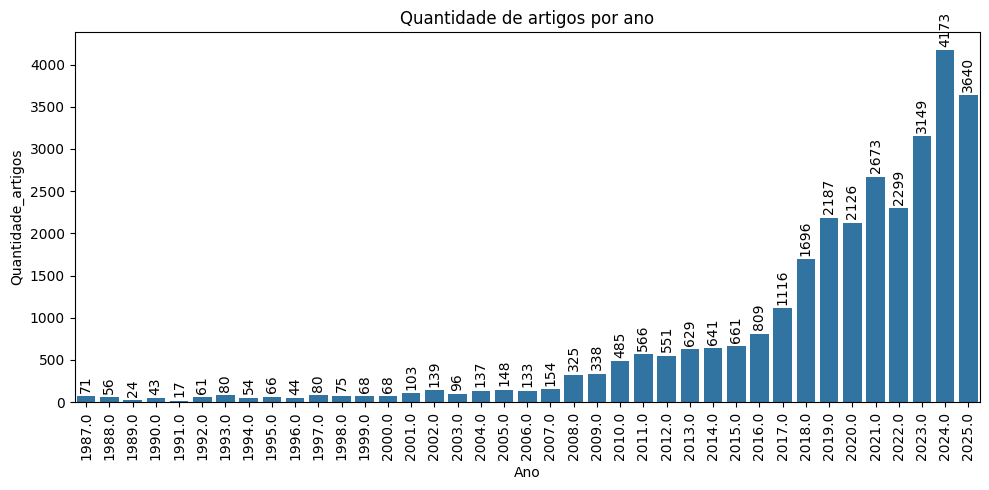

In [4]:
# Gráfico 1. Total de artigos científicos obtidos após a extração da SOL-LIB 

plt.figure(figsize=(10,5))
ax = sns.barplot(data=artigos_por_ano, x="Ano", y="Quantidade_artigos")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2., p.get_height() + 40),  # deslocamento maior
        ha='center',
        va='bottom',
        rotation=90
    )

plt.xticks(rotation=90)

plt.title("Quantidade de artigos por ano")
plt.tight_layout()
plt.savefig("artigos_por_ano_sbc.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# Criar variável indicadora de autoria principal feminina
df_artigos['Primeira_Autora_Feminina'] = (df_artigos['Sexo_Primeiro_Autor'].str.upper().eq('F')).astype(int)

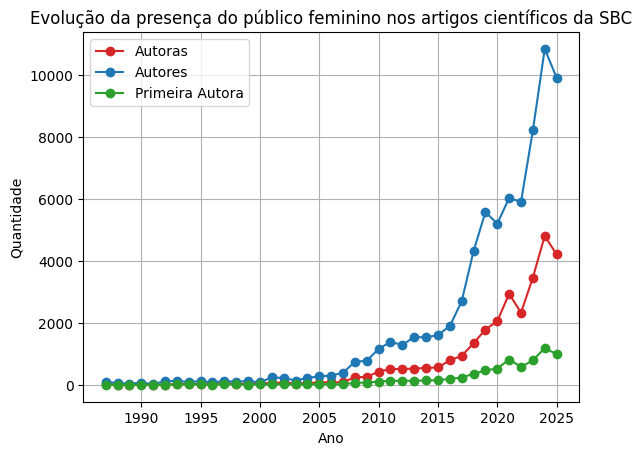

In [6]:
# Gráfico 2. Evolução da presença do público feminino nos artigos científicos da SBC

evolucao_por_ano = (
    df_artigos
        .groupby('Ano', dropna=False)
        .agg(
            Autoras=('Qtd_Autores_Feminino', 'sum'),
            Autores=('Qtd_Autores_Masculino', 'sum'),
            Primeiras_Autoras=('Primeira_Autora_Feminina', 'sum')
        )
        .sort_index()
)

plt.figure()
plt.plot(evolucao_por_ano.index, evolucao_por_ano['Autoras'], marker='o', color='tab:red', label='Autoras')
plt.plot(evolucao_por_ano.index, evolucao_por_ano['Autores'], marker='o', color='tab:blue', label='Autores')
plt.plot(evolucao_por_ano.index, evolucao_por_ano['Primeiras_Autoras'], marker='o', color='tab:green', label='Primeira Autora')

plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.title('Evolução da presença do público feminino nos artigos científicos da SBC')
plt.legend()
plt.grid(True)
plt.savefig("evolucao_publico_feminino_artigos_sbc.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Total de artigos por Evento e Ano
total_artigos = (
    df_artigos
    .groupby(['Event','Ano'], dropna=False)
    .agg(
        Total_Artigos=('id_artigo','count')
    )
    .reset_index()
)

# Indicadores principais
indicadores_base = (
    df_artigos
    .groupby(['Event','Ano'], dropna=False)
    .agg(
        Total_Autoras=('Qtd_Autores_Feminino','sum'), # Indicador 1
        Total_Autores_Masculinos=('Qtd_Autores_Masculino','sum'), # Indicador 2
        Primeiras_Autoras=('Primeira_Autora_Feminina','sum'), # Indicador 3
        Total_Autores=('Qtd_Autores_Total','sum') # Indicador 4
    )
    .reset_index()
)

# # Indicador 5 - Total de primeiros autores masculinos
indicadores_base['Primeiros_Autores_Masculinos'] = (
    total_artigos['Total_Artigos'] - indicadores_base['Primeiras_Autoras']
)

# Junta total de artigos
indicadores = indicadores_base.merge(
    total_artigos,
    on=['Event','Ano'],
    how='left'
)

# Indicador 6 - Proporção de autoras
indicadores['Proporcao_Autoras'] = (
    indicadores['Total_Autoras'] / indicadores['Total_Autores']
)

# Indicador 7 - Proporção de primeiras autoras
indicadores['Proporcao_Primeiras_Autoras'] = (
    indicadores['Primeiras_Autoras'] / indicadores['Total_Artigos']
)


# Indicador 8 - Média de mulheres em artigos liderados por mulheres
lideranca_feminina = (
    df_artigos[df_artigos['Primeira_Autora_Feminina'] == 1]
    .groupby(['Event','Ano'], dropna=False)
    .agg(
        Soma_Autoras_Fem_Lideranca_Fem=('Qtd_Autores_Feminino','sum'),
        Total_Artigos_Lideranca_Fem=('id_artigo','count')
    )
    .reset_index()
)

lideranca_feminina['Media_Autoras_Lideranca_Feminina'] = (
    lideranca_feminina['Soma_Autoras_Fem_Lideranca_Fem'] /
    lideranca_feminina['Total_Artigos_Lideranca_Fem']
)

# Indicador 9 - Média de mulheres em artigos liderados por homens
lideranca_masculina = (
    df_artigos[df_artigos['Primeira_Autora_Feminina'] == 0]
    .groupby(['Event','Ano'], dropna=False)
    .agg(
        Soma_Autoras_Fem_Lideranca_Masc=('Qtd_Autores_Feminino','sum'),
        Total_Artigos_Lideranca_Masc=('id_artigo','count')
    )
    .reset_index()
)

lideranca_masculina['Media_Autoras_Lideranca_Masculina'] = (
    lideranca_masculina['Soma_Autoras_Fem_Lideranca_Masc'] /
    lideranca_masculina['Total_Artigos_Lideranca_Masc']
)


resultado_final = (
    indicadores
    .merge(
        lideranca_feminina[['Event','Ano','Media_Autoras_Lideranca_Feminina']],
        on=['Event','Ano'],
        how='left'
    )
    .merge(
        lideranca_masculina[['Event','Ano','Media_Autoras_Lideranca_Masculina']],
        on=['Event','Ano'],
        how='left'
    )
)

# Ordena para facilitar análise
resultado_final = resultado_final.sort_values(
    by=['Event','Ano']
)

In [8]:
resultado_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Event                              1200 non-null   object 
 1   Ano                                1200 non-null   float64
 2   Total_Autoras                      1201 non-null   int64  
 3   Total_Autores_Masculinos           1201 non-null   int64  
 4   Primeiras_Autoras                  1201 non-null   int64  
 5   Total_Autores                      1201 non-null   int64  
 6   Primeiros_Autores_Masculinos       1201 non-null   int64  
 7   Total_Artigos                      1201 non-null   int64  
 8   Proporcao_Autoras                  1200 non-null   float64
 9   Proporcao_Primeiras_Autoras        1201 non-null   float64
 10  Media_Autoras_Lideranca_Feminina   1030 non-null   float64
 11  Media_Autoras_Lideranca_Masculina  1199 non-null   float

In [9]:
# Exporta CSV
resultado_final.to_csv(
    '9_indicadores_participacao_feminina_evento_ano.csv',
    index=False,
    sep=',',
    decimal=',',
    encoding='utf-8-sig',
    float_format='%.4f'
)

A partir do 9_indicadores_participacao_feminina_evento_ano.csv, foi feita a categorização dos eventos em áreas temáticas, resultando no dataset a seguir: 10_indicadores_participacao_feminina_categoria_evento_ano.csv


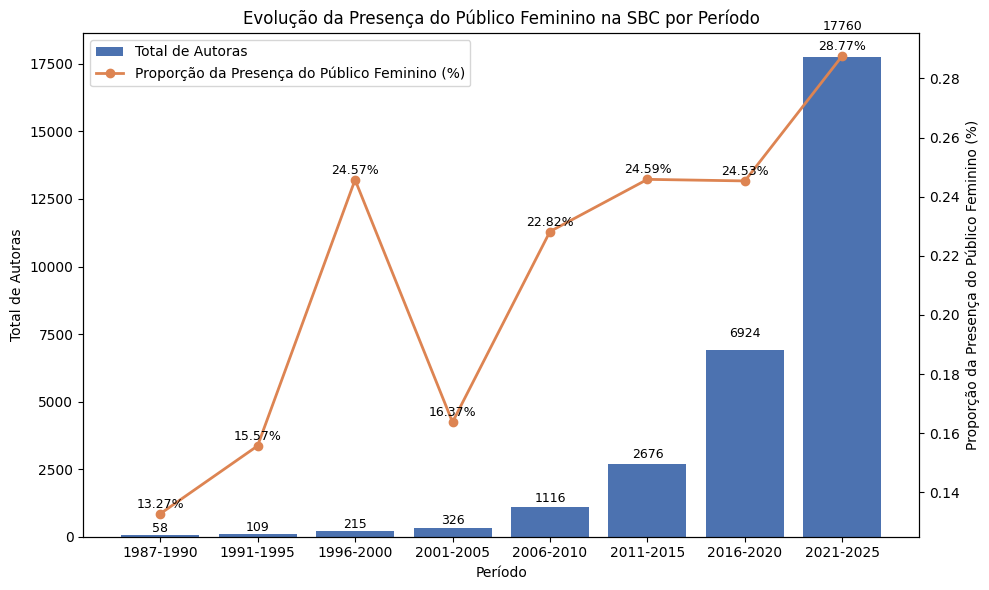

In [13]:
df = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\10_indicadores_participacao_feminina_categoria_evento_ano.csv') 

def classificar_periodo(ano):
    if 1987 <= ano <= 1990:
        return '1987-1990'
    elif 1991 <= ano <= 1995:
        return '1991-1995'
    elif 1996 <= ano <= 2000:
        return '1996-2000'
    elif 2001 <= ano <= 2005:
        return '2001-2005'
    elif 2006 <= ano <= 2010:
        return '2006-2010'
    elif 2011 <= ano <= 2015:
        return '2011-2015'
    elif 2016 <= ano <= 2020:
        return '2016-2020'
    elif 2021 <= ano <= 2025:
        return '2021-2025'
    else:
        return np.nan

df['Periodo'] = df['Ano'].apply(classificar_periodo)

# Agrupar por período e calcular os totais de autoras e autores
periodo_stats = (
    df.groupby('Periodo')
      .agg(
          Total_Autoras_Periodo=('Total_Autoras','sum'),
          Total_Autores_Periodo=('Total_Autores','sum')
      )
      .reset_index()
)

# Calcular a proporção de autoras para cada período
periodo_stats['Participacao_Feminina'] = (
    periodo_stats['Total_Autoras_Periodo'] /
    periodo_stats['Total_Autores_Periodo']
)

# Gráfico de barras para o total de autoras por período e linha para a proporção de presença feminina
fig, ax1 = plt.subplots(figsize=(10,6))

cor_barras = '#4C72B0'
cor_linha = '#DD8452'

bars = ax1.bar(
    periodo_stats['Periodo'],
    periodo_stats['Total_Autoras_Periodo'],
    color=cor_barras,
    label='Total de Autoras'
)

ax1.set_ylabel('Total de Autoras')
ax1.set_xlabel('Período')

# valores das barras (com pequeno offset)
for bar in bars:
    altura = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        altura + (altura * 0.05),
        f'{int(altura)}',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(
    periodo_stats['Periodo'],
    periodo_stats['Participacao_Feminina'],
    marker='o',
    linewidth=2,
    color=cor_linha,
    label='Proporção da Presença do Público Feminino (%)'
)

ax2.set_ylabel('Proporção da Presença do Público Feminino (%)')

# valores da linha (deslocados um pouco para cima)
for x, y in zip(periodo_stats['Periodo'], periodo_stats['Participacao_Feminina']):
    ax2.text(
        x,
        y + 0.001,
        f'{y:.2%}',
        ha='center',
        va='bottom',
        fontsize=9
    )

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.title('Evolução da Presença do Público Feminino na SBC por Período')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

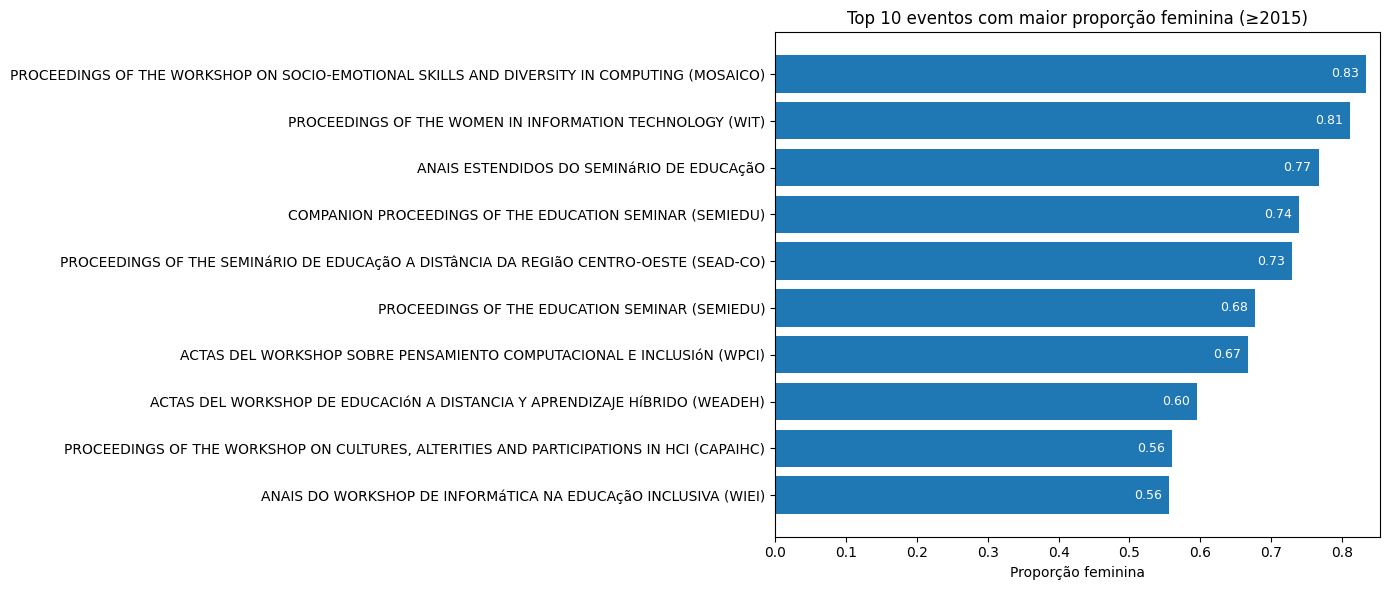

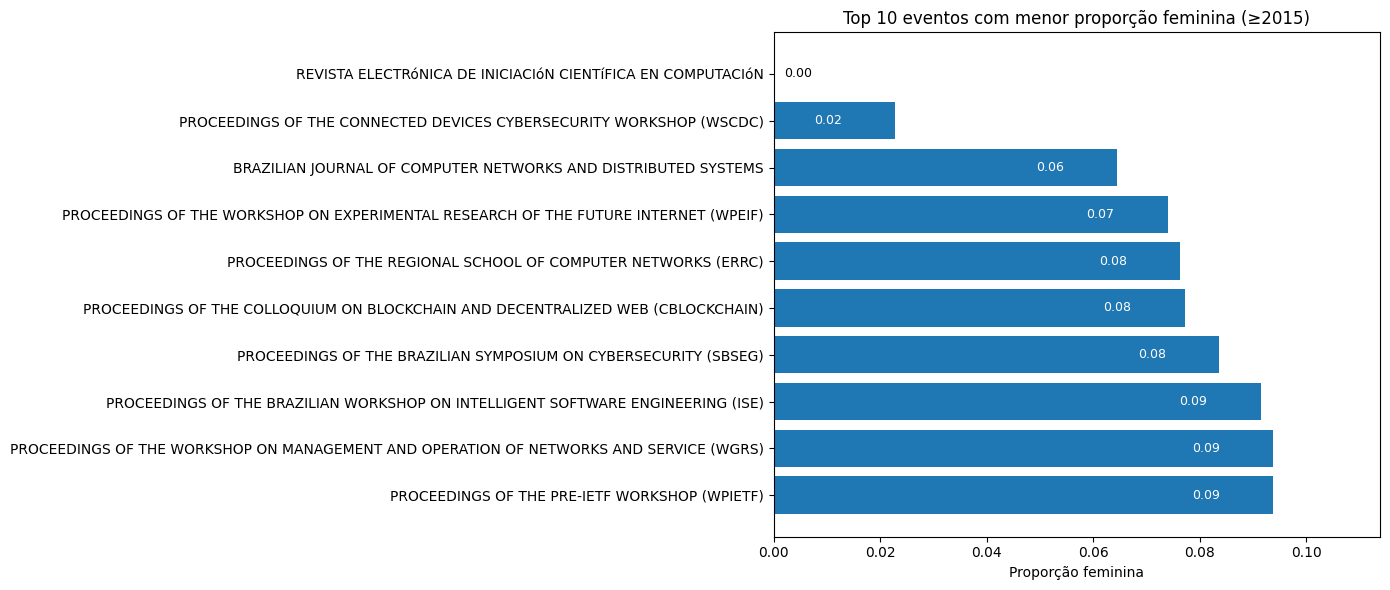

In [18]:
df = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\10_indicadores_participacao_feminina_categoria_evento_ano.csv') 

df = df[df["Ano"] >= 2015]

def classificar_periodo(ano):
    if 1987 <= ano <= 1990:
        return '1987-1990'
    elif 1991 <= ano <= 1995:
        return '1991-1995'
    elif 1996 <= ano <= 2000:
        return '1996-2000'
    elif 2001 <= ano <= 2005:
        return '2001-2005'
    elif 2006 <= ano <= 2010:
        return '2006-2010'
    elif 2011 <= ano <= 2015:
        return '2011-2015'
    elif 2016 <= ano <= 2020:
        return '2016-2020'
    elif 2021 <= ano <= 2025:
        return '2021-2025'
    else:
        return np.nan

df['Periodo'] = df['Ano'].apply(classificar_periodo)

df["Proporcao_Autoras"] = (
    df["Proporcao_Autoras"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

proporcao_eventos = (df.groupby("Event")["Proporcao_Autoras"].mean().reset_index())


# Selecionar Top 10 maiores e menores
top10_maior = (
    proporcao_eventos
    .sort_values("Proporcao_Autoras", ascending=False)
    .head(10)
)

top10_menor = (
    proporcao_eventos
    .sort_values("Proporcao_Autoras", ascending=True)
    .head(10)
)

# GRÁFICO - MAIOR PROPORÇÃO FEMININA
plt.figure(figsize=(14,6))

plt.barh(
    top10_maior["Event"],
    top10_maior["Proporcao_Autoras"]
)

plt.xlabel("Proporção feminina")
plt.title("Top 10 eventos com maior proporção feminina (≥2015)")
plt.gca().invert_yaxis()

# inserir valores nas barras
for i, v in enumerate(top10_maior["Proporcao_Autoras"]):

    if v > 0:
        plt.text(
            v - 0.01,
            i,
            f"{v:.2f}",
            va="center",
            ha="right",
            color="white",
            fontsize=9
        )

    else:
        plt.text(
            0.002,
            i,
            f"{v:.2f}",
            va="center",
            ha="left",
            fontsize=9
        )

plt.xlim(0, top10_maior["Proporcao_Autoras"].max() + 0.02)

plt.tight_layout()
plt.show()


# GRÁFICO 2 - MENOR PROPORÇÃO FEMININA
plt.figure(figsize=(14,6))

plt.barh(
    top10_menor["Event"],
    top10_menor["Proporcao_Autoras"]
)

plt.xlabel("Proporção feminina")
plt.title("Top 10 eventos com menor proporção feminina (≥2015)")
plt.gca().invert_yaxis()

# inserir valores nas barras
for i, v in enumerate(top10_menor["Proporcao_Autoras"]):

    if v > 0:
        plt.text(
            v - 0.01,
            i,
            f"{v:.2f}",
            va="center",
            ha="right",
            color="white",
            fontsize=9
        )

    else:
        plt.text(
            0.002,
            i,
            f"{v:.2f}",
            va="center",
            ha="left",
            fontsize=9
        )

plt.xlim(0, top10_menor["Proporcao_Autoras"].max() + 0.02)

plt.tight_layout()
plt.show()

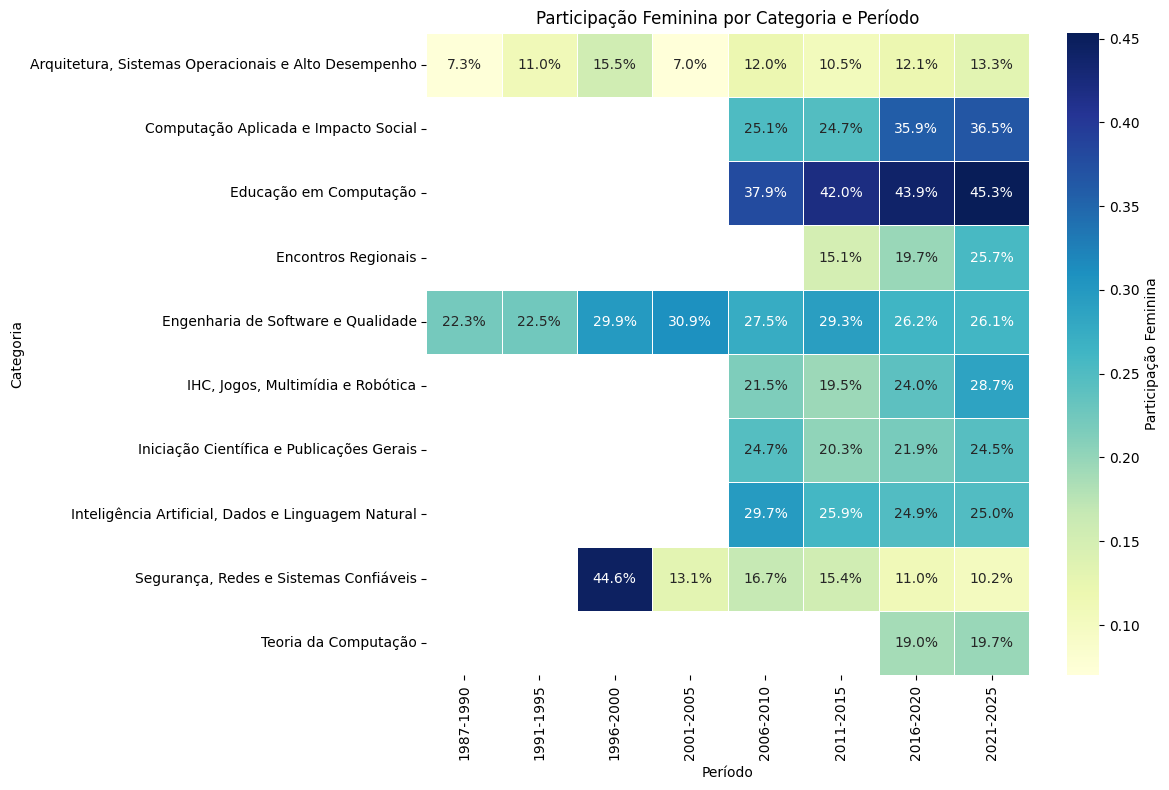

In [21]:
# Gráfico - Análise da proporção de autoras por Categoria de Evento 

df = pd.read_csv('C:\\Users\\Thiago Lobo\\WIT-Project-Research\\autorship-analysis\\10_indicadores_participacao_feminina_categoria_evento_ano.csv')

def classificar_periodo(ano):
    if 1987 <= ano <= 1990:
        return '1987-1990'
    elif 1991 <= ano <= 1995:
        return '1991-1995'
    elif 1996 <= ano <= 2000:
        return '1996-2000'
    elif 2001 <= ano <= 2005:
        return '2001-2005'
    elif 2006 <= ano <= 2010:
        return '2006-2010'
    elif 2011 <= ano <= 2015:
        return '2011-2015'
    elif 2016 <= ano <= 2020:
        return '2016-2020'
    elif 2021 <= ano <= 2025:
        return '2021-2025'
    else:
        return np.nan

df['Periodo'] = df['Ano'].apply(classificar_periodo)

# Agrupar por Categoria e Periodo
categoria_periodo = (
    df.groupby(['Categoria','Periodo'])
      .agg(
          Total_Autoras=('Total_Autoras','sum'),
          Total_Autores=('Total_Autores','sum')
      )
      .reset_index()
)

# Calcular participação feminina
categoria_periodo['Participacao_Feminina'] = (
    categoria_periodo['Total_Autoras'] /
    categoria_periodo['Total_Autores']
)

# Criar matriz Categoria x Periodo
matriz = categoria_periodo.pivot(
    index='Categoria',
    columns='Periodo',
    values='Participacao_Feminina'
)

ordem_periodos = [
    '1987-1990','1991-1995','1996-2000','2001-2005',
    '2006-2010','2011-2015','2016-2020','2021-2025'
]

matriz = matriz[ordem_periodos]

# Plot Heatmap
plt.figure(figsize=(12,8))

ax = sns.heatmap(
    matriz,
    annot=True,
    fmt=".1%",
    cmap="YlGnBu",
    linewidths=0.5,
    cbar_kws={'label': 'Participação Feminina'}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

plt.title('Participação Feminina por Categoria e Período')
plt.xlabel('Período')
plt.ylabel('Categoria')

plt.tight_layout()
plt.show()

### Análise de Temáticas

In [ ]:
# Filtrar artigos com ao menos uma autora
df_filtrado = (df_artigos.loc[(df_artigos['Qtd_Autores_Feminino'] >= 1)].copy())

print(df_filtrado.shape)

df_filtrado.to_csv('10_artigos_com_uma_autora.csv', index=False)

In [ ]:
# Análise de Frequência Palavras ou Bigramas nos Abstracts de Artigos com ao menos uma autora

todas_palavras = []

# abstract_pre_processado_limpo ou abstract_bigramas
for tokens in df_filtrado["abstract_pre_processado_limpo"].dropna():
    todas_palavras.extend(tokens)

frequencia = Counter(todas_palavras)

# converter para dataframe
df_frequencia = (
    pd.DataFrame(frequencia.items(), columns=["Palavra", "Frequencia"])
    .sort_values(by="Frequencia", ascending=False)
)

print(df_frequencia.head(50))

#df_frequencia.to_csv('frequencia_palavras_abstracts.csv', index=False)

#### BERTopic

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
import ast

df_filtrado = pd.read_csv('10_artigos_com_uma_autora.csv')

df_filtrado['abstract_pre_processado_limpo'] = df_filtrado['abstract_pre_processado_limpo'].apply(ast.literal_eval)

df_filtrado['abstract_bertopic'] = df_filtrado['abstract_pre_processado_limpo'].apply(lambda x: " ".join(x))

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

umap_model = umap.UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.05,
    metric='cosine',
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=30,
    min_samples=7,
    metric='euclidean',
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    ngram_range=(1,2),
    min_df=1,
    token_pattern=r"(?u)\b\w+\b"
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

docs = df_filtrado['abstract_bertopic'].tolist()

topics, probs = topic_model.fit_transform(docs)

In [ ]:
df_filtrado["topic"] = topics

In [ ]:
topic_model.get_topic_info()

In [ ]:
topic_labels = {
4: "Blockchain Security Attacks",
-1: "Data Use in Education",
15: "Robotic Systems and Environments",
49: "Autonomous Vehicles and Drones",
13: "Autism Spectrum Disorder",
11: "Educational Robotics",
54: "Dengue Monitoring and Aedes Aegypti",
6: "Computational Thinking",
32: "Scientific Collaboration",
41: "Data Privacy and LGPD",
0: "Software Development and Testing",
30: "UX and Usability Design",
16: "Open Government and Public Data",
5: "Large Language Models (Portuguese)",
53: "Neural Networks for Image Processing",
46: "Data Labeling and Dataset Classification",
63: "Lung Disease Diagnosis",
52: "Forest Fire and Deforestation Monitoring",
36: "Database Query and Similarity Search",
8: "Smart Cities and Urban Data",
19: "Breast Cancer Detection",
23: "ECG Diagnosis Models",
55: "Fake News Detection",
29: "Water Resources and Precipitation Forecasting",
1: "Digital Games",
47: "Student Dropout in Higher Education",
45: "Computing Education Curriculum",
25: "Chatbots and Conversational Agents",
20: "COVID-19 Pandemic Studies",
26: "Bioinformatics and Genomics",
33: "Sign Language and Deaf Communication",
38: "Distance Higher Education",
57: "Emotion Recognition",
17: "Coffee Leaf Disease Detection",
7: "Social Media and Twitter Analysis",
31: "Brazilian Scientific Publications",
51: "Test Smell Detection",
37: "Music Information Processing",
60: "Crime and Police Data Analysis",
10: "Virtual Reality Systems",
2: "Gender and Women in Computing",
3: "Parallel Computing Performance",
28: "Mobile App Accessibility",
35: "Cloud Computing Services",
14: "Accessibility for Visually Impaired",
43: "Ethics in Human-Computer Interaction",
58: "Data Visualization",
56: "Ontology and Semantic Web",
21: "Health Information Systems",
61: "Women in Gaming",
12: "Digital Technologies in Teaching",
44: "Recommender Systems",
9: "Network Protocols and Communication",
34: "Graph Algorithms",
48: "Algorithmic Problem Solving",
62: "Collaborative Crowdsourcing",
50: "Internet of Things",
18: "Articles Without Abstract",
66: "Network Virtualization",
24: "Programming Education",
39: "Digital TV and Ginga",
42: "Gamification in Education",
67: "Technical Debt",
22: "Virtual Learning Environments",
27: "Remote Education During Pandemic",
59: "Scientific Workflows",
40: "School Education Research",
65: "Fault Injection and Detection",
64: "Racial and Ethnic Studies"
}

In [ ]:
topic_info = topic_model.get_topic_info()

labels = [
    topic_labels.get(topic, str(topic))
    for topic in topic_info.Topic
]

topic_model.set_topic_labels(labels)

In [ ]:
topic_info = topic_model.get_topic_info()
topic_names = dict(zip(topic_info["Topic"], topic_info["Name"]))
df_filtrado["topic_name"] = df_filtrado["topic"].map(topic_names)

In [ ]:
df_filtrado["topic_label_renomeado"] = df_filtrado["topic"].map(topic_labels)

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.set_topic_labels(topic_labels)

In [ ]:
fig = topic_model.visualize_hierarchy(
    custom_labels=True
)

fig.show()

In [ ]:
topic_model.visualize_barchart(top_n_topics=20)

In [48]:
df = pd.read_csv('11_artigos_com_uma_autora_clusterizados.csv')

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16641 entries, 0 to 16640
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Unnamed: 0                     16641 non-null  int64 
 1   Title                          16641 non-null  object
 2   Category                       16641 non-null  object
 3   URL_Title                      16641 non-null  object
 4   Authors                        16641 non-null  object
 5   Event                          16641 non-null  object
 6   Date                           16641 non-null  object
 7   Abstract                       16641 non-null  object
 8   autores_tratados               16641 non-null  object
 9   Sexo_Primeiro_Autor            16641 non-null  object
 10  Qtd_Autores_Feminino           16641 non-null  int64 
 11  Qtd_Autores_Masculino          16641 non-null  int64 
 12  Qtd_Autores_Unknown            16641 non-null  int64 
 13  Q

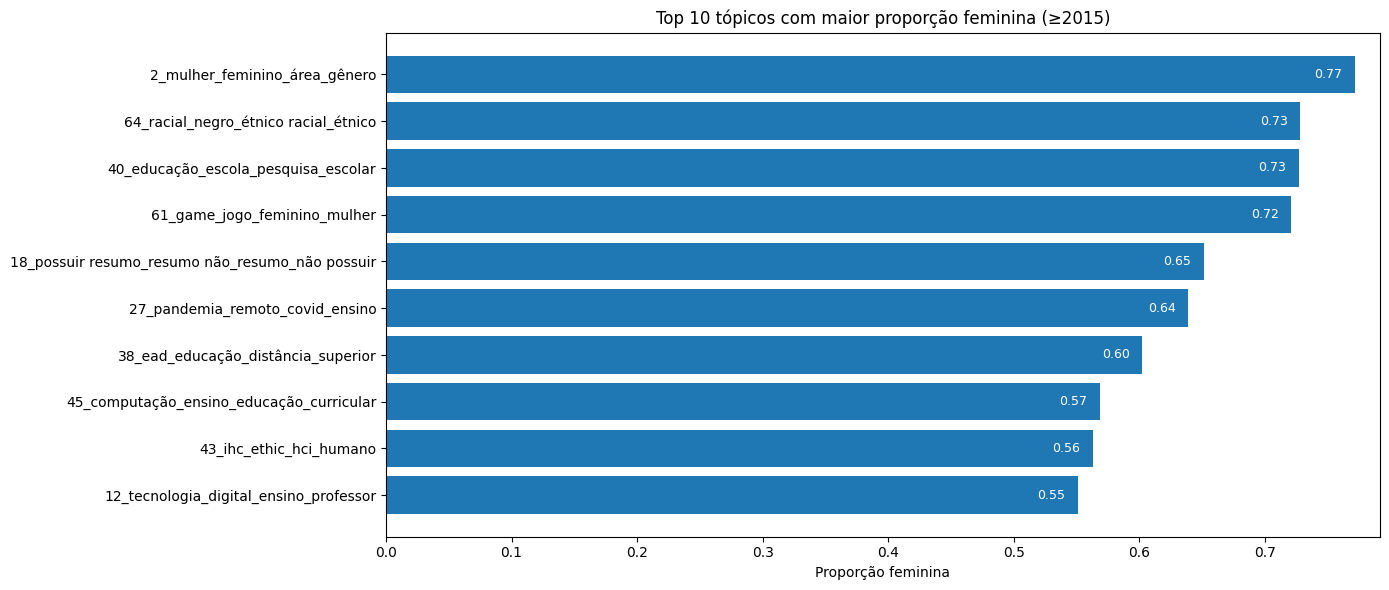

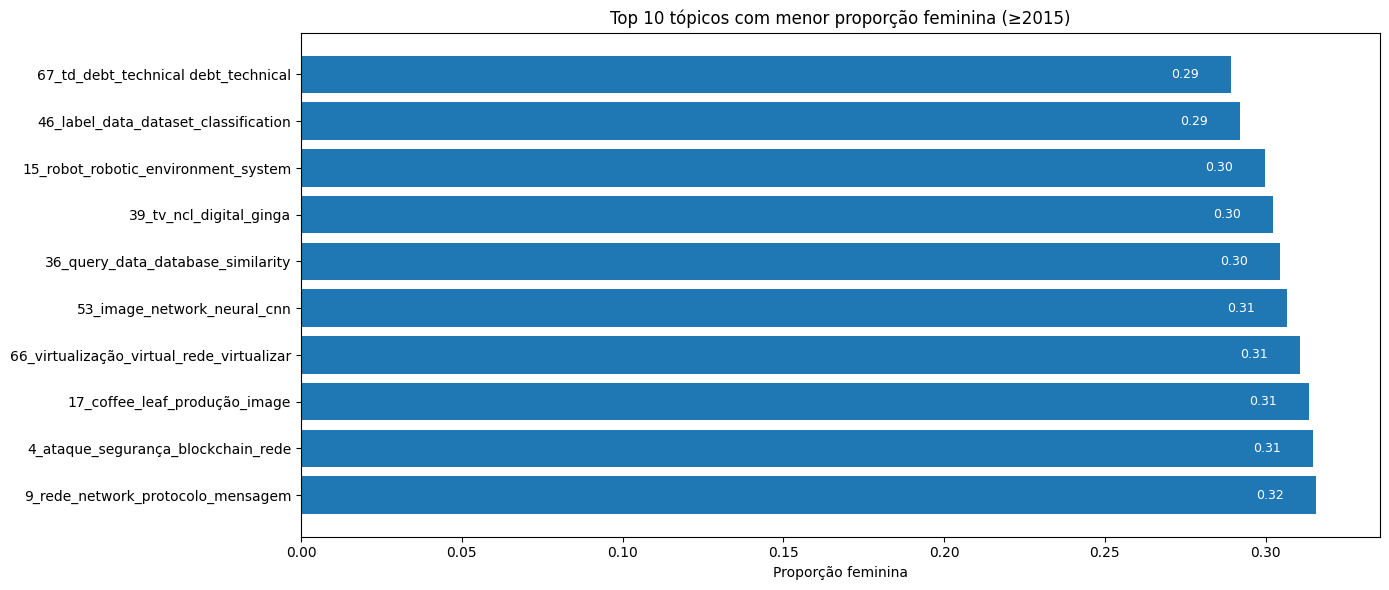

In [50]:
df = df[df["Ano"] >= 2015].copy()

# -------------------------
# 2. Agregar por topic_name
# -------------------------
proporcao_topics = (
    df.groupby("topic_name")
    .agg({
        "Qtd_Autores_Feminino": "sum",
        "Qtd_Autores_Total": "sum"
    })
    .reset_index()
)

# calcular proporção
proporcao_topics["Proporcao_Autoras"] = (
    proporcao_topics["Qtd_Autores_Feminino"] /
    proporcao_topics["Qtd_Autores_Total"]
)

# -------------------------
# 3. Selecionar Top 10 maiores e menores
# -------------------------
top10_maior = (
    proporcao_topics
    .sort_values("Proporcao_Autoras", ascending=False)
    .head(10)
)

top10_menor = (
    proporcao_topics
    .sort_values("Proporcao_Autoras", ascending=True)
    .head(10)
)

# ==========================================================
# GRÁFICO 1 - MAIOR PROPORÇÃO FEMININA
# ==========================================================

plt.figure(figsize=(14,6))

plt.barh(
    top10_maior["topic_name"],
    top10_maior["Proporcao_Autoras"]
)

plt.xlabel("Proporção feminina")
plt.title("Top 10 tópicos com maior proporção feminina (≥2015)")
plt.gca().invert_yaxis()

for i, v in enumerate(top10_maior["Proporcao_Autoras"]):

    if v > 0:
        plt.text(
            v - 0.01,
            i,
            f"{v:.2f}",
            va="center",
            ha="right",
            color="white",
            fontsize=9
        )
    else:
        plt.text(
            0.002,
            i,
            f"{v:.2f}",
            va="center",
            ha="left",
            fontsize=9
        )

plt.xlim(0, top10_maior["Proporcao_Autoras"].max() + 0.02)

plt.tight_layout()
plt.show()


# ==========================================================
# GRÁFICO 2 - MENOR PROPORÇÃO FEMININA
# ==========================================================

plt.figure(figsize=(14,6))

plt.barh(
    top10_menor["topic_name"],
    top10_menor["Proporcao_Autoras"]
)

plt.xlabel("Proporção feminina")
plt.title("Top 10 tópicos com menor proporção feminina (≥2015)")
plt.gca().invert_yaxis()

for i, v in enumerate(top10_menor["Proporcao_Autoras"]):

    if v > 0:
        plt.text(
            v - 0.01,
            i,
            f"{v:.2f}",
            va="center",
            ha="right",
            color="white",
            fontsize=9
        )
    else:
        plt.text(
            0.002,
            i,
            f"{v:.2f}",
            va="center",
            ha="left",
            fontsize=9
        )

plt.xlim(0, top10_menor["Proporcao_Autoras"].max() + 0.02)

plt.tight_layout()
plt.show()